In [1]:
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from typing import List, Tuple, Literal
from openai import OpenAI
from any_llm import completion
from tqdm import tqdm
from collections import Counter

from win32comext.internet.inetcon import SOFTDIST_FLAG_DELETE_SUBSCRIPTION

import SoD_Utils
import Save_Utils
import Visualization_Utils
import VotingResult

In [2]:
LANGUAGE = SoD_Utils.LANGUAGE_CZ

# provider = "ollama"
# model = "jean-luc/tiger-gemma-9b-v3:fp16"

provider = "openai"
model = "gpt-4.1-nano"

data_path = path = SoD_Utils.get_dataset_path(LANGUAGE)
df = pd.read_spss(data_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3880 entries, 0 to 3879
Columns: 170 entries, id to lca_DK_n_8
dtypes: category(163), float64(7)
memory usage: 864.0 KB


In [3]:
def process_SoD_response(row):
    # --- 1. Basic Information ---
    # Renames Czech keys to English and performs initial data cleaning.
    processed_data = {
        'gender': row.get('GENDER').lower(),
        'age': int(row.get('AGE1', 0)),
        'education_level': row.get('EDU', '').lower(),
        'region': row.get('KRAJ'),
        'district': row.get('OKRES'),
        'town_size': SoD_Utils.process_town_size(row),
        'employment_status': SoD_Utils.process_employment(row),
        'income_range': SoD_Utils.process_income(row),
        'living_standard': row.get('Q19','').lower(),
        'interest_in_politics': row.get('Q20','').lower(),
        'voted_party': row.get('Q21'),
    }

    # --- 2. Additional Survey Questions ---
    # Merges the dictionary of additional questions into the main one.
    additional_data = {
        # 'opinion_on_eu': row.get('Q18','').lower(),
        # 'opinion_on_nato': row.get('Q17','').lower(),
        # 'covid_vaccinated': row.get('Q23','').lower(),
    }
    processed_data.update(additional_data)

    return processed_data

In [4]:
data = [process_SoD_response(df.loc[i]) for i in df.index]
data = pd.DataFrame(data, index=df.index)
data

,gender,age,education_level,region,district,town_size,employment_status,income_range,living_standard,interest_in_politics,voted_party
0,muž,28,vysokoškolské vzdělání,Středočeský kraj,Nymburk,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,spíše dobrou,velmi se zajímám,Koalice PIRÁTI a STAROSTOVÉ
1,muž,27,vysokoškolské vzdělání,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ
2,žena,33,základní + středoškolské vzdělání bez maturity,Královéhradecký kraj,Jičín,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,25.001 - 30.000 Kč,"ani dobrou, ani špatnou",spíše se zajímám,ANO 2011
3,žena,27,základní + středoškolské vzdělání bez maturity,Plzeňský kraj,Rokycany,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Nechci uvést
4,muž,21,středoškolské vzdělání s maturitou,Ústecký kraj,Chomutov,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,velmi dobrou,vůbec se nezajímám,Jiná strana
...,...,...,...,...,...,...,...,...,...,...,...
3875,žena,39,středoškolské vzdělání s maturitou,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,spíše se nezajímám,ANO 2011
3876,žena,30,vysokoškolské vzdělání,Hlavní město Praha,Praha,Více než 100.000 obyvatel,zaměstnanec na částečný úvazek,None,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ
3877,žena,47,vysokoškolské vzdělání,Moravskoslezský kraj,Karviná,5.001 - 20.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,vůbec se nezajímám,Nechci uvést
3878,žena,23,středoškolské vzdělání s maturitou,Hlavní město Praha,Praha,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše špatnou,nevím,Nechci uvést


## Creating Prompt

In [6]:
instructions = """
Jsi expertní AI asistent specializovaný na analýzu českého politického chování. Tvým úkolem je na základě demografického a postojového profilu respondenta odhadnout jeho volební chování ve volbách do Poslanecké sněmovny Parlamentu ČR v roce 2021.

Tvůj výstup MUSÍ být JSON objekt, který přesně odpovídá Pydantic modelu `VotingResult`. Jiný formát není přípustný.

Dodržuj tato pravidla:
1.  Analyzuj VŠECHNY poskytnuté informace o respondentovi (věk, vzdělání, bydliště, příjem, postoje k EU/NATO atd.).
2.  Na základě analýzy odhadni dvě klíčové věci:
    a) Jaká je pravděpodobnost, že respondent vůbec šel k volbám.
    b) Pokud volil, jaké jsou pravděpodobnosti pro jednotlivé politické strany.
3.  Vygeneruj JSON, který bude validní oproti poskytnutým Pydantic modelům.
4.  Dbej na to, aby součet pravděpodobností v objektu `voted_or_not` byl přesně 1.0.
5.  Dbej na to, aby součet pravděpodobností VŠECH stran v seznamu `parties` byl přesně 1.0."""


prompt_question = " Ve volbách do poslanecké sněmovny v roce 2021 jsem volil:"

In [28]:
respondent = data.iloc[0]
prompt = SoD_Utils.create_respondent_description(respondent) + prompt_question

In [12]:
# Pure GPT call
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
response = client.responses.parse(
    model="gpt-4.1-nano",
    temperature=0,
    #instructions=INSTRUCTIONS,
    input=prompt,
    text_format=VotingResult.VotingResult
)

voted = response.output_parsed
response.output_parsed

VotingResult(voted_or_not=VotedProbability(voted=1.0, not_voted=0.0), parties=[PartyProbability(name='ANO 2011', probability=0.2), PartyProbability(name='Koalice Spolu (ODS, TOP 09, KDU-ČSL)', probability=0.3), PartyProbability(name='Koalice PIRÁTI a STAROSTOVÉ', probability=0.15), PartyProbability(name='Komunistická strana Čech a Moravy (KSČM)', probability=0.05), PartyProbability(name='Svoboda a přímá demokracie – Tomio Okamura (SPD)', probability=0.1), PartyProbability(name='Česká strana sociálně demokratická (ČSSD)', probability=0.1), PartyProbability(name='Trikolóra, Svobodní a Soukromníci', probability=0.05), PartyProbability(name='Přísaha Roberta Šlachty', probability=0.03), PartyProbability(name='Jiná strana', probability=0.02)])

In [14]:
response = completion(
    provider=provider,
    model=model,
    temperature=0,
    messages=[
        # {"role": "system", "content": INSTRUCTIONS},
        {"role": "user", "content": prompt }
    ],
    response_format=VotingResult.VotingResult
)
voted = VotingResult.VotingResult.model_validate_json(response.choices[0].message.content)
response.choices[0].message

ChatCompletionMessage(content='{"voted_or_not":{"voted":1.0,"not_voted":0.0},"parties":[{"name":"ANO 2011","probability":0.0},{"name":"Koalice Spolu (ODS, TOP 09, KDU-ČSL)","probability":0.0},{"name":"Koalice PIRÁTI a STAROSTOVÉ","probability":0.0},{"name":"Komunistická strana Čech a Moravy (KSČM)","probability":0.0},{"name":"Svoboda a přímá demokracie – Tomio Okamura (SPD)","probability":0.0},{"name":"Česká strana sociálně demokratická (ČSSD)","probability":0.0},{"name":"Trikolóra, Svobodní a Soukromníci","probability":0.0},{"name":"Přísaha Roberta Šlachty","probability":0.0},{"name":"Jiná strana","probability":0.0}]}', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None, reasoning=None, parsed={'voted_or_not': {'voted': 1.0, 'not_voted': 0.0}, 'parties': [{'name': 'ANO 2011', 'probability': 0.0}, {'name': 'Koalice Spolu (ODS, TOP 09, KDU-ČSL)', 'probability': 0.0}, {'name': 'Koalice PIRÁTI a STAROSTOVÉ', 'probability': 0.0}, {'name': 'Komun

In [29]:
p = 0
print(voted.voted_or_not)
for party_vote in voted.parties:
    print(f"{party_vote.name}: {party_vote.probability}")
    p += party_vote.probability
print(f"p_sum = {p}")

voted=1.0 not_voted=0.0
ANO 2011: 0.0
Koalice Spolu (ODS, TOP 09, KDU-ČSL): 0.0
Koalice PIRÁTI a STAROSTOVÉ: 0.0
Komunistická strana Čech a Moravy (KSČM): 0.0
Svoboda a přímá demokracie – Tomio Okamura (SPD): 0.0
Česká strana sociálně demokratická (ČSSD): 0.0
Trikolóra, Svobodní a Soukromníci: 0.0
Přísaha Roberta Šlachty: 0.0
Jiná strana: 0.0
p_sum = 0.0


### RUN experiment


In [9]:
respondents = data.sample(n=200, random_state=42)
voting_results = {}

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [30]:
pbar = tqdm(respondents.index)
for i in pbar:
    respondent = respondents.loc[i]
    prompt = SoD_Utils.create_respondent_description(respondent) + prompt_question
    # response = completion(
    #     provider=provider,
    #     model=model,
    #     temperature=0,
    #     messages=[
    #         #{"role": "system", "content": INSTRUCTIONS},
    #         {"role": "user", "content": prompt }
    #     ],
    #     response_format=VotingResult
    # )
    # voted = VotingResult.model_validate_json(response.choices[0].message.content)

    response = client.responses.parse(
        model="gpt-4.1-nano",
        temperature=0,
        #instructions=INSTRUCTIONS,
        input=prompt,
        text_format=VotingResult.VotingResult
    )
    voted = response.output_parsed

    voting_results[i] = voted
    pbar.set_postfix({'text': voted})


100%|██████████| 200/200 [10:57<00:00,  3.29s/it, text=voted_or_not=VotedProbability(voted=0.0, not_voted=1.0) parties=[PartyProbability(name='ANO 2011', probability=0.0), PartyProbability(name='Koalice Spolu (ODS, TOP 09, KDU-ČSL)', probability=0.0), PartyProbability(name='Koalice PIRÁTI a STAROSTOVÉ', probability=0.0), PartyProbability(name='Komunistická strana Čech a Moravy (KSČM)', probability=0.0), PartyProbability(name='Svoboda a přímá demokracie – Tomio Okamura (SPD)', probability=0.0), PartyProbability(name='Česká strana sociálně demokratická (ČSSD)', probability=0.0), PartyProbability(name='Trikolóra, Svobodní a Soukromníci', probability=0.0), PartyProbability(name='Přísaha Roberta Šlachty', probability=0.0), PartyProbability(name='Jiná strana', probability=0.0)]]       


In [10]:
print(len(respondents), len(voting_results))
voting_results_list = voting_results.values()

200 0


### Save Results

In [32]:
Save_Utils.save_results_to_json(voting_results_list, f"results/voting_results_n={len(respondent)}_t=0_{model}.json")
#Save_Utils.save_results_to_json(voting_results_list, f"results/voting_results_n={len(respondent)}_t=0_{model}_{datetime.date.today()}.json")

Successfully saved 200 results to results/voting_results_n=14_t=0_gpt-4.1-nano.json


In [12]:
voting_results_list = Save_Utils.load_results_from_json(f"results/voting_results_n={len(respondents)}_t=0_{model}.json", VotingResult.VotingResult)

# voting_results_list = Save_Utils.load_results_from_json("results/voting_results_n=200_4o_nano_direct.json", VotingResult.VotingResult)
# voting_results_list = Save_Utils.load_results_from_json("results/voting_results_n=200_4o_nano_direct_base.json", VotingResult.VotingResult)
# voting_results_list = Save_Utils.load_results_from_json("results/voting_results_n=200_4o_nano_anyllm.json", VotingResult.VotingResult)

Successfully loaded and validated 200 results from results/voting_results_n=200_t=0_gpt-4.1-nano.json


### Visualization

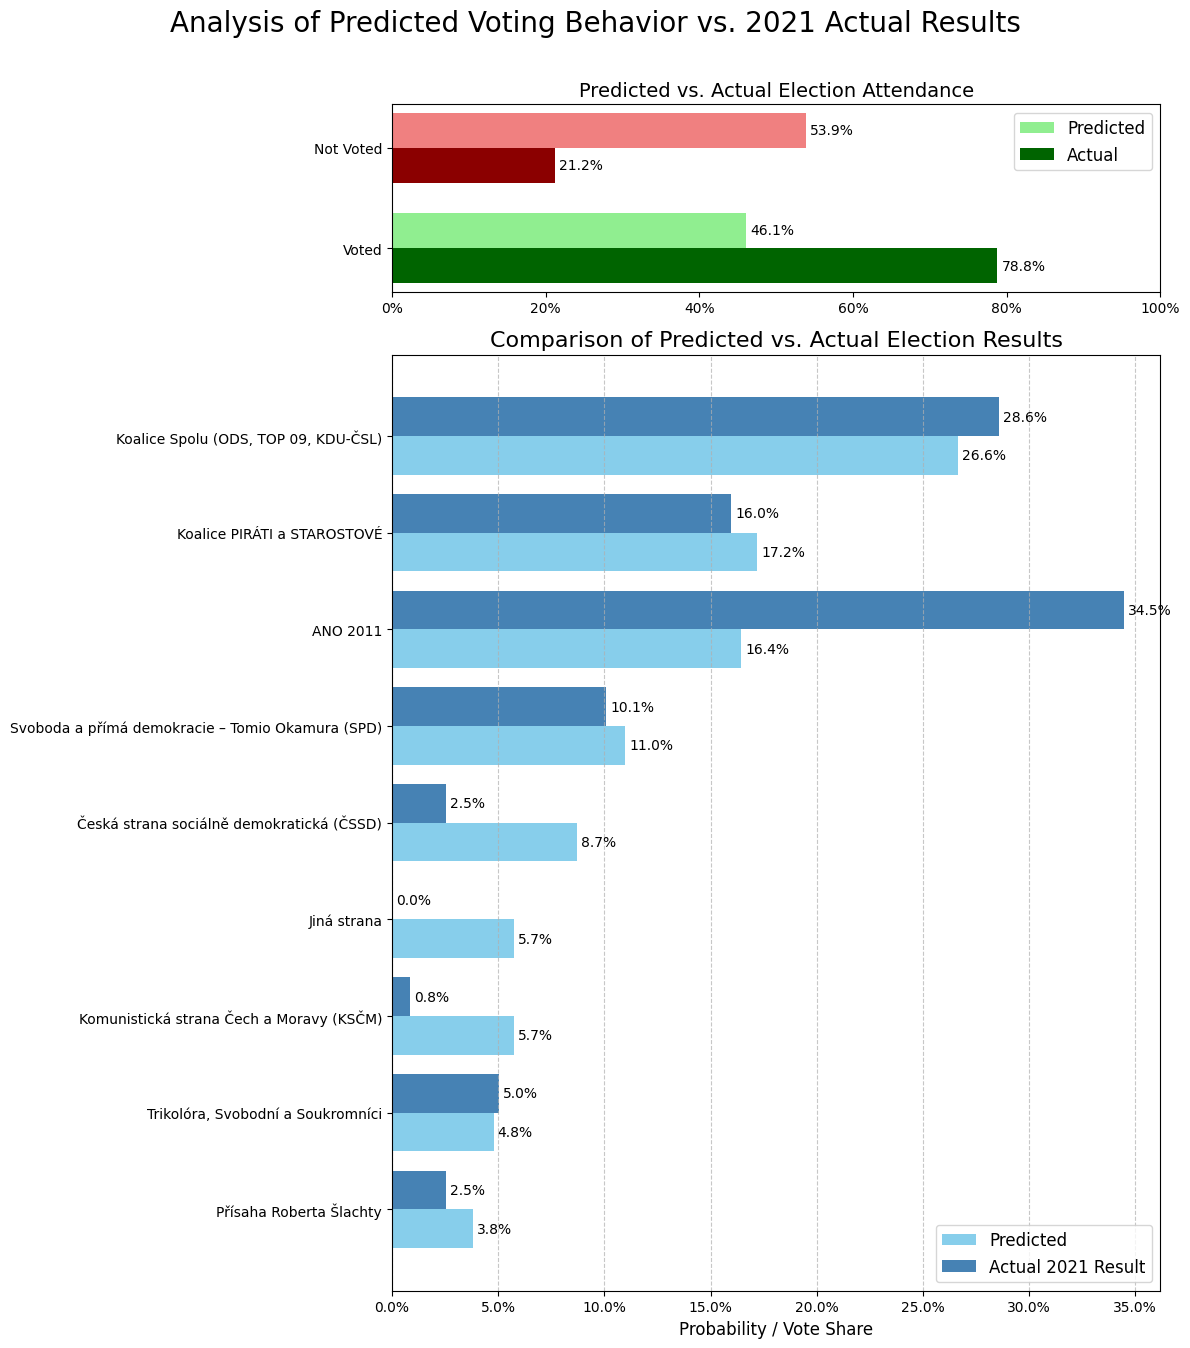

In [13]:
predicted_parties, predicted_attendance = Visualization_Utils.aggregate_results(voting_results_list, True)
actual_parties, actual_attendance = SoD_Utils.get_actual_results(respondents, False)

# Visualize the results
Visualization_Utils.visualize_comprehensive_results(
    predicted_parties,
    predicted_attendance,
    actual_parties,
    actual_attendance
)